# N1 — Camera–LiDAR Projection & Back-Projection

Project between 3D LiDAR point clouds and 2D camera images using the [KITTI Vision Benchmark](http://www.cvlibs.net/datasets/kitti/).

```
     FORWARD  (3D → 2D)               BACKWARD  (2D → 3D)
                                        + ground-plane constraint
3D Point (X,Y,Z,1)                 2D Pixel (u, v)
       │                                 │
   Tr_velo_to_cam                    M⁻¹ with Z = z_ground
       │                                 │
     R0_rect                         3D Point (X, Y, z_ground)
       │
      P2
       │
  2D Pixel (u, v) + depth
```

## 1. Install and Import Dependencies

In [ ]:
%pip install pykitti numpy matplotlib opencv-python-headless --quiet
%pip install "transformers==4.46.3" --quiet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import pykitti
import os

print("All libraries loaded successfully!")

## The Pinhole Camera Model

**Extrinsic [R | t]** — rigid-body transform from world to camera coordinates.

**Intrinsic K** — maps camera-frame 3D points to pixel coordinates:

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

**Full projection** (homogeneous):

$$s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = K \cdot [R \mid \mathbf{t}] \cdot \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}$$

Divide by $s$ to get pixel $(u, v)$. Depth is lost — recovery requires a constraint (ground plane) or a second sensor (LiDAR).

### KITTI Coordinate Frames

| Frame | X | Y | Z |
|-------|---|---|---|
| **Velodyne** | Forward | Left | Up |
| **Camera** | Right | Down | Forward |
| **Image** | Right (u) | Down (v) | — |

## 2. Download KITTI Sample Data

Synchronized camera images, LiDAR scans, and calibration files from the KITTI benchmark. KITTI is a widely used autonomous driving benchmark recorded in southwestern Germany.

In [ ]:
import urllib.request
import zipfile
import shutil

# You can find more data at https://www.cvlibs.net/datasets/kitti/raw_data.php
KITTI_BASE = "kitti_data"
DATE = "2011_09_26"
DRIVE = "0005"

calib_url = f"https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/{DATE}_calib.zip"
drive_url = f"https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/{DATE}_drive_{DRIVE}/{DATE}_drive_{DRIVE}_sync.zip"

def download_and_extract(url, extract_to, description):
    zip_name = url.split("/")[-1]
    zip_path = os.path.join(extract_to, zip_name)

    target_check = os.path.join(extract_to, DATE)
    if description == "drive data":
        target_check = os.path.join(extract_to, DATE, f"{DATE}_drive_{DRIVE}_sync")

    if os.path.exists(target_check):
        print(f"  {description} already exists, skipping download.")
        return

    os.makedirs(extract_to, exist_ok=True)
    print(f"  Downloading {description} ...")
    urllib.request.urlretrieve(url, zip_path)
    print(f"  Extracting ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    os.remove(zip_path)
    print(f"  Done.")

print("Downloading KITTI sample data...\n")
download_and_extract(calib_url, KITTI_BASE, "calibration files")
download_and_extract(drive_url, KITTI_BASE, "drive data")

print(f"\nData ready at: {os.path.abspath(KITTI_BASE)}")

## 3. Load Data with pykitti

In [ ]:
# Load one drive session. pykitti lazily reads files from disk and also
# parses the calibration files (data.calib) needed to relate sensors.
data = pykitti.raw(KITTI_BASE, DATE, DRIVE)

FRAME_IDX = 0 

# Camera 2 = the LEFT COLOR camera (cam0/1 are grayscale, cam2/3 are color).
# Most KITTI vision work uses cam2 as the reference image.
img = np.array(data.get_cam2(FRAME_IDX))

# Velodyne LiDAR scan: (N, 4) float32 array, roughly ~120k points per frame.
# Columns are X, Y, Z, reflectance — in the VELODYNE coordinate frame, not the camera's:
# Reflectance is in [0, 1] (surface return intensity, useful as an extra feature).
# To overlay points on the image you must transform them with the calibration
# matrices (data.calib.T_cam2_velo etc.) — the frames are NOT aligned by default.
velo = data.get_velo(FRAME_IDX)

print(f"Image shape:        {img.shape}  (H x W x C)")
print(f"Point cloud shape:  {velo.shape}  (N points x [X, Y, Z, reflectance])")
print(f"Point cloud range:  X [{velo[:,0].min():.1f}, {velo[:,0].max():.1f}]  "
      f"Y [{velo[:,1].min():.1f}, {velo[:,1].max():.1f}]  "
      f"Z [{velo[:,2].min():.1f}, {velo[:,2].max():.1f}]")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.imshow(img)
ax.set_title("Camera 2 — Frame 0", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Raw 3D Point Cloud

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
scatter = ax.scatter(velo[:, 0], velo[:, 1], c=velo[:, 2], cmap="viridis",
                     s=0.3, alpha=0.5, vmin=-2, vmax=1)
ax.set_xlabel("X — forward (m)")
ax.set_ylabel("Y — left (m)")
ax.set_title("Bird's-Eye View")
ax.set_aspect("equal")
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)
plt.colorbar(scatter, ax=ax, label="Z (m)")

ax = axes[1]
scatter = ax.scatter(velo[:, 1], velo[:, 2], c=velo[:, 0], cmap="plasma",
                     s=0.3, alpha=0.5, vmin=0, vmax=50)
ax.set_xlabel("Y — left (m)")
ax.set_ylabel("Z — up (m)")
ax.set_title("Front View")
ax.set_aspect("equal")
ax.set_xlim(-30, 30)
ax.set_ylim(-3, 10)
plt.colorbar(scatter, ax=ax, label="Depth (m)")

plt.tight_layout()
plt.show()

print(f"Total points: {len(velo):,}")

## 5. Sensor Calibration

Before any projection math, let's look at where the calibration actually lives. KITTI ships it as plain-text files — one per sensor pair:

| File | Transform |
|------|-----------|
| `calib_velo_to_cam.txt` | LiDAR → Camera 0 |
| `calib_imu_to_velo.txt` | IMU/GPS → LiDAR |
| `calib_cam_to_cam.txt` | Camera 0 → Cameras 0–3 |

Each stores a rotation **R** (3×3) and translation **T** (3×1), combined as:

<!-- $$T = egin{bmatrix} R & \mathbf{t} \ \mathbf{0}^T & 1 \end{bmatrix}$$ -->

We parse `calib_velo_to_cam.txt` by hand to see exactly what's inside:

In [ ]:
def parse_kitti_rigid_calib(filepath):
    """Parse a KITTI calibration file containing R (3x3) and T (3x1)."""
    fields = {}
    with open(filepath) as f:
        for line in f:
            if ':' in line:
                key, val = line.strip().split(':', 1)
                fields[key.strip()] = val.strip()
    R = np.array([float(x) for x in fields['R'].split()]).reshape(3, 3)
    T = np.array([float(x) for x in fields['T'].split()])
    return R, T

calib_vc_path = os.path.join(KITTI_BASE, DATE, "calib_velo_to_cam.txt")
R_vc_file, T_vc_file = parse_kitti_rigid_calib(calib_vc_path)

Tr_vc_file = np.eye(4)
Tr_vc_file[:3, :3] = R_vc_file
Tr_vc_file[:3, 3] = T_vc_file

print("Velodyne → Camera 0 (4x4 homogeneous):")
print(np.array2string(Tr_vc_file, precision=4, suppress_small=True))
print(f"\nSensor offset: {abs(T_vc_file[0])*100:.1f} cm lateral, "
      f"{abs(T_vc_file[1])*100:.1f} cm vertical, "
      f"{abs(T_vc_file[2])*100:.1f} cm depth")

### IMU → Velodyne Calibration

Both frames use X-forward, Y-left, Z-up — so R is near-identity. The transform is dominated by the physical offset between sensors.

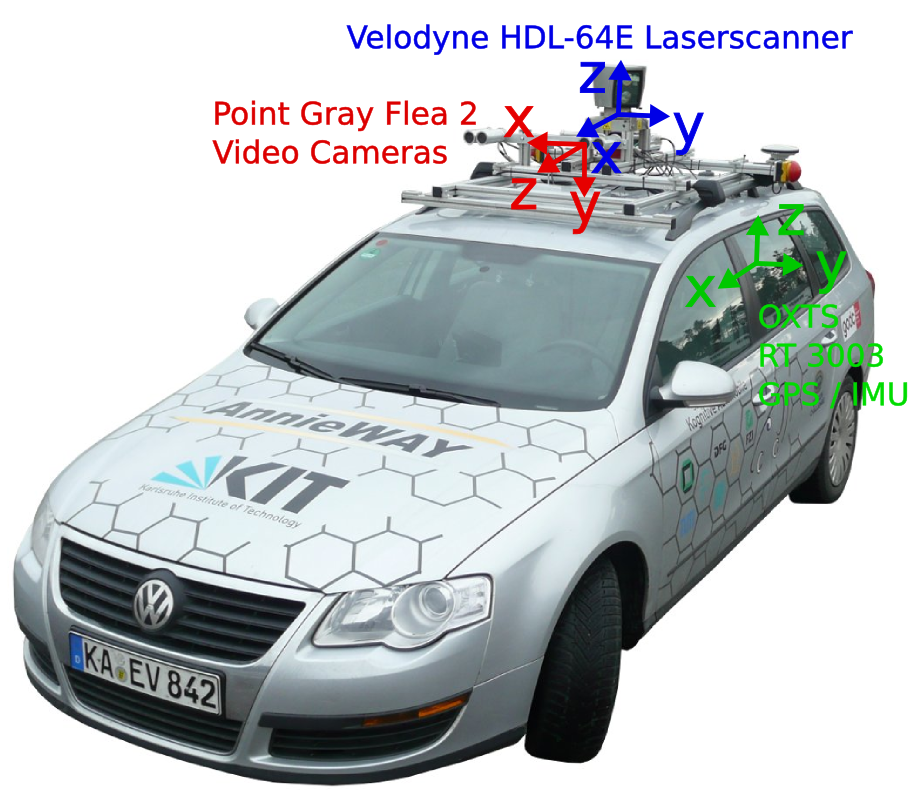

In [ ]:
calib_iv_path = os.path.join(KITTI_BASE, DATE, "calib_imu_to_velo.txt")
R_iv_file, T_iv_file = parse_kitti_rigid_calib(calib_iv_path)

Tr_iv_file = np.eye(4)
Tr_iv_file[:3, :3] = R_iv_file
Tr_iv_file[:3, 3] = T_iv_file

angle_iv = np.degrees(np.arccos(np.clip((np.trace(R_iv_file) - 1) / 2, -1, 1)))
print(f"IMU → Velodyne rotation: {angle_iv:.2f}° (near identity)")
print(f"Translation: [{T_iv_file[0]:.3f}, {T_iv_file[1]:.3f}, {T_iv_file[2]:.3f}] m")

# Sensor frame visualization
cam_origin = -R_vc_file.T @ T_vc_file
cam_axes = R_vc_file.T
imu_origin = T_iv_file.copy()
imu_axes = R_iv_file.copy()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

arrow_len = 0.12
rgb = ['#d62728', '#2ca02c', '#1f77b4']

sensor_frames = [
    (np.zeros(3), np.eye(3), "VELODYNE", 'black'),
    (cam_origin, cam_axes, "CAMERA 0", '#1f77b4'),
    (imu_origin, imu_axes, "IMU / GPS", '#e67e22'),
]

axis_labels = ['X', 'Y', 'Z']
for origin, axes_mat, name, name_clr in sensor_frames:
    for i, (c, lbl) in enumerate(zip(rgb, axis_labels)):
        d = axes_mat[:, i] * arrow_len
        ax.quiver(*origin, *d, color=c, linewidth=2, arrow_length_ratio=0.1)
    ax.scatter(*origin, color=name_clr, s=80, zorder=5, edgecolors='white', linewidths=0.5)
    ax.text(origin[0], origin[1], origin[2] - arrow_len * 0.5,
            name, fontsize=10, fontweight='bold', ha='center', color=name_clr)

for other in [cam_origin, imu_origin]:
    ax.plot(*zip(np.zeros(3), other), 'k--', linewidth=0.8, alpha=0.3)
    mid = other / 2
    ax.text(mid[0], mid[1] + 0.03, mid[2], f"{np.linalg.norm(other):.2f} m",
            fontsize=8, color='gray')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('KITTI Sensor Frames (in Velodyne coordinates)', fontsize=13)
ax.view_init(elev=20, azim=-50)

all_origins = np.vstack([np.zeros(3), cam_origin, imu_origin])
center = all_origins.mean(axis=0)
span = max(np.ptp(all_origins, axis=0).max() * 0.65, 0.3)
for setter, c_val in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], center):
    setter(c_val - span, c_val + span)

plt.tight_layout()
plt.show()

### Calibration Matrices

With the raw files understood, we load the three matrices that chain to project a LiDAR point onto the image — `pykitti` assembles them from the files above (and folds in stereo rectification):

| Matrix | Shape | Purpose |
|--------|-------|---------|
| **Tr_velo_to_cam** | 4×4 | Velodyne → Camera 0 rigid-body transform |
| **R0_rect** | 4×4 | Stereo rectification rotation |
| **P2** | 3×4 | Camera 2 projection (intrinsics + baseline) |

$$\mathbf{y} = P_2 \cdot R_{0,	ext{rect}} \cdot T_{	ext{velo→cam}} \cdot \mathbf{X}$$

Divide by $z$ to get pixel $(u, v)$ and depth.

In [ ]:
T_cam_velo = np.array(data.calib.T_cam0_velo) # Camera to velodyne calibration
R0_rect = np.array(data.calib.R_rect_00) # Camera rotation

if R0_rect.shape == (3, 3):
    R0_ext = np.eye(4)
    R0_ext[:3, :3] = R0_rect
else:
    R0_ext = R0_rect

P2 = np.array(data.calib.P_rect_20) # K * [1 | t]

print(f"Tr_velo_to_cam  {T_cam_velo.shape}")
print(f"R0_rect         {R0_ext.shape}")
print(f"P2              {P2.shape}")

In [ ]:
K = P2[:3, :3]
t_cam2 = np.linalg.solve(K, P2[:, 3])

print(f"Intrinsic K:  fx={K[0,0]:.1f}  fy={K[1,1]:.1f}  cx={K[0,2]:.1f}  cy={K[1,2]:.1f}")
print(f"Baseline:     t=[{t_cam2[0]:.4f}, {t_cam2[1]:.4f}, {t_cam2[2]:.4f}] m")

## 6. Project LiDAR onto Camera Image

In [ ]:
def project_velo_to_cam2(velo_points, T_cam_velo, R0_rect, P2, img_shape):
    """
    Project Velodyne points onto Camera 2 image plane.

    Returns:
        pts_2d: (M, 2) pixel coordinates [u, v]
        depths: (M,)   depth in camera frame
    """
    pts_3d = velo_points[:, :3]

    # Step 1: Filter points in front of the LiDAR (positive X in velodyne frame)
    front_mask = pts_3d[:, 0] > 0
    pts_3d = pts_3d[front_mask]

    # Step 2: Convert to homogeneous coordinates (N, 4)
    ones = np.ones((pts_3d.shape[0], 1))
    pts_3d_hom = np.hstack([pts_3d, ones])  # (N, 4)

    # Step 3: Velodyne -> Camera 0 reference frame  (4x4 @ 4xN = 4xN)
    pts_cam = T_cam_velo @ pts_3d_hom.T

    # Step 4: Apply rectification
    # R0_rect may be 3x3 or 4x4 depending on pykitti version — normalize to 4x4
    if R0_rect.shape == (3, 3):
        R0_ext = np.eye(4)
        R0_ext[:3, :3] = R0_rect
    else:
        R0_ext = R0_rect
    pts_cam_rect = R0_ext @ pts_cam  # (4, N)

    # Step 5: Project to image plane with P2  (3x4 @ 4xN = 3xN)
    pts_2d_hom = P2 @ pts_cam_rect

    # Step 6: Normalize by depth (divide by z)
    depths = pts_2d_hom[2, :]
    pts_2d = pts_2d_hom[:2, :] / depths  # (2, N)
    pts_2d = pts_2d.T  # (N, 2) -> [u, v]

    # Step 7: Filter to points within image boundaries and positive depth
    h, w = img_shape[:2]
    valid = (
        (depths > 0) &
        (pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < w) &
        (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < h)
    )

    return pts_2d[valid], depths[valid]

pts_2d, depths = project_velo_to_cam2(velo, T_cam_velo, R0_rect, P2, img.shape)

print(f"Original points:   {len(velo):,}")
print(f"Projected & valid: {len(pts_2d):,}")
print(f"Depth range:       {depths.min():.1f} m  to  {depths.max():.1f} m")

## 7. LiDAR Projection Result

Each point colored by depth — warm = close, cool = far.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.imshow(img)
scatter = ax.scatter(pts_2d[:, 0], pts_2d[:, 1],
                     c=depths, cmap="jet_r", s=1, alpha=0.7,
                     vmin=0, vmax=50)
plt.colorbar(scatter, ax=ax, label="Depth (m)", shrink=0.7)
ax.set_title("LiDAR → Camera 2 Projection", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Depth-Filtered Views

In [ ]:
depth_ranges = [
    (0, 10,  "Near (0–10 m)"),
    (10, 25, "Mid (10–25 m)"),
    (25, 80, "Far (25–80 m)"),
]

fig, axes = plt.subplots(len(depth_ranges), 1, figsize=(16, 5 * len(depth_ranges)))

for ax, (d_min, d_max, label) in zip(axes, depth_ranges):
    mask = (depths >= d_min) & (depths < d_max)
    ax.imshow(img)
    if mask.sum() > 0:
        ax.scatter(pts_2d[mask, 0], pts_2d[mask, 1],
                   c=depths[mask], cmap="jet_r", s=2, alpha=0.8,
                   vmin=d_min, vmax=d_max)
    ax.set_title(f"{label} — {mask.sum():,} points", fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2D → 3D Back-Projection

Forward projection loses depth. Constraining to the ground plane ($Z = z_\text{ground}$) makes the system solvable. We use **SegFormer** to identify road pixels, then back-project them.

<!-- Given $M = P_2 \cdot R_0 \cdot T_{\text{velo→cam}}$ and known $z_g$, eliminating $s$ yields a 2×2 system (Cramer's rule):

$$\begin{bmatrix} m_{00} - u m_{20} & m_{01} - u m_{21} \\ m_{10} - v m_{20} & m_{11} - v m_{21} \end{bmatrix} \begin{bmatrix} X \\ Y \end{bmatrix} = \begin{bmatrix} u c - a \\ v c - b \end{bmatrix}$$

where $a = m_{02} z_g + m_{03}$, $\; b = m_{12} z_g + m_{13}$, $\; c = m_{22} z_g + m_{23}$. -->

In [ ]:
%pip install transformers torch torchvision --quiet

import torch
import torchvision
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from PIL import Image
import torch.nn.functional as F

# SegFormer pre-trained on Cityscapes (19 urban classes: road, car, person, ...)
model_name = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # use the H100 MIG slice if present
processor = SegformerImageProcessor.from_pretrained(model_name)
seg_model = SegformerForSemanticSegmentation.from_pretrained(model_name).to(DEVICE)
seg_model.eval()   # inference mode — we're not training
print(f"SegFormer running on: {DEVICE}")

# The processor resizes + normalizes the image into the tensor the model expects
inputs = processor(images=Image.fromarray(img), return_tensors="pt").to(DEVICE)
# autocast = FP16 (half precision) on GPU: ~2x faster, negligible effect on an argmax mask
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
    logits = seg_model(**inputs).logits   # one score per class, per pixel (low-res)

# The model outputs a low-res class map — upsample back to full image size,
# then argmax picks the most likely class for every pixel
upsampled = F.interpolate(logits, size=img.shape[:2], mode="bilinear", align_corners=False)
seg_mask = upsampled.argmax(dim=1).squeeze().cpu().numpy()

# Class index in seg_mask -> name (Cityscapes ordering)
CITYSCAPES_LABELS = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck', 'bus', 'train',
    'motorcycle', 'bicycle'
]

# Boolean masks: True where a pixel was classified as that surface
road_mask = seg_mask == 0
sidewalk_mask = seg_mask == 1

# Paint the masks in solid color, then blend 50/50 with the original image
overlay = img.copy()
overlay[road_mask] = [0, 200, 0]
overlay[sidewalk_mask] = [200, 0, 0]
blended = cv2.addWeighted(img, 0.5, overlay, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].imshow(img)
axes[0].set_title("Original", fontsize=13)
axes[0].axis("off")

axes[1].imshow(blended)
axes[1].set_title("Road (green) / Sidewalk (red)", fontsize=13)
axes[1].axis("off")

axes[2].imshow(road_mask, cmap="Greens")
axes[2].set_title("Road Mask", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Road: {road_mask.sum():,} px ({road_mask.mean()*100:.1f}%)  |  "
      f"Sidewalk: {sidewalk_mask.sum():,} px ({sidewalk_mask.mean()*100:.1f}%)")

### Road Surface → Bird's-Eye View

Back-project road pixels to the ground plane and render a top-down metric view.


Given $M = P_2 \cdot R_0 \cdot T_{\text{velo→cam}}$ and known $z_g$, eliminating $s$ yields a 2×2 system (Cramer's rule):

$$\begin{bmatrix} m_{00} - u m_{20} & m_{01} - u m_{21} \\ m_{10} - v m_{20} & m_{11} - v m_{21} \end{bmatrix} \begin{bmatrix} X \\ Y \end{bmatrix} = \begin{bmatrix} u c - a \\ v c - b \end{bmatrix}$$

where $a = m_{02} z_g + m_{03}$, $\; b = m_{12} z_g + m_{13}$, $\; c = m_{22} z_g + m_{23}$.

In [ ]:
# Estimate the ground plane height from LiDAR: take a patch of points right
# in front of the car (3-25 m ahead, within 6 m laterally) — mostly road —
# and use the 5th percentile of z as the road height (robust to obstacles)
ground_candidates = velo[
    (velo[:, 0] > 3) & (velo[:, 0] < 25) &
    (np.abs(velo[:, 1]) < 6)
]
z_ground = np.percentile(ground_candidates[:, 2], 5)
print(f"Ground plane: z = {z_ground:.3f} m")

# The full projection chain from section 5, composed into ONE 3x4 matrix:
# Velodyne 3D point -> image pixel
M = P2 @ R0_ext @ T_cam_velo  # (3, 4)

def backproject_to_ground(pixels_uv, M, z_ground):
    """Back-project 2D pixels to 3D points on the ground plane.

    Projection is normally one-way: a pixel only defines a RAY in 3D,
    the depth along it is lost. But if we ASSUME the pixel lies on flat
    ground (Z = z_ground), only X and Y remain unknown.

    The projection equation  depth·[u, v, 1]ᵀ = M·[X, Y, z_ground, 1]ᵀ
    then unfolds into 2 linear equations in those 2 unknowns —
    one 2x2 system per pixel, solvable exactly.
    """
    u = pixels_uv[:, 0].astype(np.float64)
    v = pixels_uv[:, 1].astype(np.float64)

    # The known z folds into constants: a, b, c absorb M's last two columns
    a = M[0, 2] * z_ground + M[0, 3]
    b = M[1, 2] * z_ground + M[1, 3]
    c = M[2, 2] * z_ground + M[2, 3]

    # Rearranged into A·[X, Y]ᵀ = rhs — one 2x2 system per pixel,
    # all pixels built at once (vectorized)
    A00 = M[0, 0] - u * M[2, 0]
    A01 = M[0, 1] - u * M[2, 1]
    A10 = M[1, 0] - v * M[2, 0]
    A11 = M[1, 1] - v * M[2, 1]
    rhs0 = u * c - a
    rhs1 = v * c - b

    # det = 0 means the pixel's ray is parallel to the ground (at the
    # horizon) — it never intersects the plane, so mark it NaN
    det = A00 * A11 - A01 * A10
    det[det == 0] = np.nan

    # Cramer's rule: closed-form solution of each 2x2 system
    X = (rhs0 * A11 - rhs1 * A01) / det
    Y = (A00 * rhs1 - A10 * rhs0) / det
    return np.stack([X, Y, np.full_like(X, z_ground)], axis=1)

# Take every road pixel from the SegFormer mask, subsampled to ~30k for speed
road_v, road_u = np.where(road_mask)
step = max(1, len(road_v) // 30000)
road_pixels = np.stack([road_u[::step], road_v[::step]], axis=1)

road_3d = backproject_to_ground(road_pixels, M, z_ground)

# Pixels near the horizon back-project to absurd distances (the ray is
# nearly parallel to the ground) — keep only points in a sane range
reasonable = (
    np.isfinite(road_3d[:, 0]) &
    (road_3d[:, 0] > 0) & (road_3d[:, 0] < 80) &
    (np.abs(road_3d[:, 1]) < 25)
)
road_3d_valid = road_3d[reasonable]
road_px_valid = road_pixels[reasonable]
# Carry each pixel's RGB along so the BEV shows the actual road texture
road_colors = img[road_px_valid[:, 1].astype(int), road_px_valid[:, 0].astype(int)] / 255.0

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

ax = axes[0]
blended_road = img.copy()
blended_road[road_mask] = (0.5 * blended_road[road_mask] + 0.5 * np.array([0, 200, 0])).astype(np.uint8)
ax.imshow(blended_road)
ax.set_title("Road Segmentation", fontsize=13)
ax.axis("off")

# BEV: plot lateral Y against forward X, looking straight down.
# The x-axis is flipped (15 -> -15) so left in the image is left in the plot.
ax = axes[1]
ax.scatter(road_3d_valid[:, 1], road_3d_valid[:, 0],
           c=road_colors, s=1, alpha=0.6)
ax.plot(0, 0, marker="^", color="red", markersize=14, zorder=10)  # ego vehicle
ax.set_xlabel("Y — lateral (m)", fontsize=12)
ax.set_ylabel("X — forward (m)", fontsize=12)
ax.set_title("Road Surface — Bird's-Eye View", fontsize=13)
ax.set_aspect("equal")
ax.set_xlim(15, -15)
ax.set_ylim(-5, 60)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Back-projected {len(road_3d_valid):,} road points")

### Road Bird's-Eye View — Video

Side-by-side: camera with road overlay (left) and metric BEV (right) across the full sequence.

In [ ]:
import io
import imageio.v3 as iio
import matplotlib

original_backend = matplotlib.get_backend()
matplotlib.use("Agg")

num_frames = min(len(data.cam2_files), 80)
bev_frames = []

print(f"Rendering {num_frames} frames: road segmentation → bird's-eye view...")
print(f"(ground plane z = {z_ground:.3f} m in Velodyne frame)\n")

for idx in range(num_frames):
    frame_img = np.array(data.get_cam2(idx))

    # Segment road surface with SegFormer
    inputs = processor(images=Image.fromarray(frame_img), return_tensors="pt").to(DEVICE)
    # autocast = FP16 (half precision) on GPU: ~2x faster, negligible effect on an argmax mask
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
        logits = seg_model(**inputs).logits
    up = F.interpolate(logits, size=frame_img.shape[:2], mode="bilinear", align_corners=False)
    frame_road = up.argmax(dim=1).squeeze().cpu().numpy() == 0

    # Back-project road pixels to ground plane
    rv, ru = np.where(frame_road)
    if len(rv) > 0:
        step_bp = max(1, len(rv) // 20000)
        road_px = np.stack([ru[::step_bp], rv[::step_bp]], axis=1)
        road_3d_frame = backproject_to_ground(road_px, M, z_ground)

        keep = (
            np.isfinite(road_3d_frame[:, 0]) &
            (road_3d_frame[:, 0] > 0) & (road_3d_frame[:, 0] < 80) &
            (np.abs(road_3d_frame[:, 1]) < 25)
        )
        road_3d_v = road_3d_frame[keep]
        road_px_v = road_px[keep]
        road_clr = frame_img[road_px_v[:, 1].astype(int),
                             road_px_v[:, 0].astype(int)] / 255.0
    else:
        road_3d_v = np.empty((0, 3))
        road_clr = np.empty((0, 3))

    # ── Render side-by-side ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=100,
                             gridspec_kw={"width_ratios": [2, 1]})

    # Left: camera image with road overlay
    blended = frame_img.copy()
    if frame_road.any():
        blended[frame_road] = (0.5 * blended[frame_road]
                               + 0.5 * np.array([0, 200, 0])).astype(np.uint8)
    axes[0].imshow(blended)
    axes[0].set_title(f"Road Segmentation — Frame {idx}", fontsize=12)
    axes[0].axis("off")

    # Right: bird's-eye view
    if len(road_3d_v) > 0:
        axes[1].scatter(road_3d_v[:, 1], road_3d_v[:, 0],
                        c=road_clr, s=1, alpha=0.6)
    axes[1].plot(0, 0, marker="^", color="red", markersize=12, zorder=10)
    axes[1].annotate("EGO", (0, 0), textcoords="offset points",
                     xytext=(8, -4), fontsize=8, fontweight="bold", color="red")
    axes[1].set_xlabel("Y — lateral (m)", fontsize=10)
    axes[1].set_ylabel("X — forward (m)", fontsize=10)
    axes[1].set_title("Bird's-Eye View (ground plane)", fontsize=12)
    axes[1].set_aspect("equal")
    axes[1].set_xlim(15, -15)
    axes[1].set_ylim(-5, 60)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_facecolor("#f0f0f0")

    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)
    bev_frames.append(iio.imread(buf))
    plt.close(fig)

    if (idx + 1) % 20 == 0:
        print(f"  Rendered {idx + 1}/{num_frames} frames")

matplotlib.use(original_backend)

output_bev = os.path.join("videos", "road_bev_video.mp4")
os.makedirs("videos", exist_ok=True)
iio.imwrite(output_bev, bev_frames, fps=10, codec="libx264")
print(f"\nVideo saved: {output_bev}  ({num_frames} frames, 10 fps)")

## Dense Depth Map from Sparse LiDAR

Interpolate sparse LiDAR depth to fill the full image.

In [ ]:
from scipy.interpolate import griddata

h, w = img.shape[:2]

points = np.column_stack([pts_2d[:, 0], pts_2d[:, 1]])
values = depths

grid_u, grid_v = np.meshgrid(np.arange(w), np.arange(h))
dense_linear = griddata(points, values, (grid_u, grid_v), method="linear")
dense_nearest = griddata(points, values, (grid_u, grid_v), method="nearest")
dense_depth = np.where(np.isnan(dense_linear), dense_nearest, dense_linear)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].imshow(img)
axes[0].set_title("Camera Image", fontsize=13)
axes[0].axis("off")

depth_vis = axes[1].imshow(dense_depth, cmap="jet_r", vmin=0, vmax=50)
axes[1].set_title("Dense Depth Map", fontsize=13)
axes[1].axis("off")
plt.colorbar(depth_vis, ax=axes[1], label="Depth (m)", shrink=0.7)

plt.tight_layout()
plt.show()

## 10. Multi-Frame Animation

In [ ]:
from IPython import display as ipd
import time

sample_frames = range(0, min(len(data.cam2_files), 50), 1)

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

for idx in sample_frames:
    frame_img = np.array(data.get_cam2(idx))
    frame_velo = data.get_velo(idx)

    pts, d = project_velo_to_cam2(frame_velo, T_cam_velo, R0_rect, P2, frame_img.shape)

    ax.clear()
    ax.imshow(frame_img)
    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], c=d, cmap="jet_r", s=1, alpha=0.7, vmin=0, vmax=50)
    ax.set_title(f"Frame {idx} — {len(pts):,} projected points", fontsize=13)
    ax.axis("off")

    ipd.clear_output(wait=True)
    ipd.display(fig)
    time.sleep(0.1)

plt.close()
print("Animation complete.")

## 11. Export as MP4 Video

In [ ]:
%pip install imageio[ffmpeg] --quiet

import io
import imageio.v3 as iio
import matplotlib

original_backend = matplotlib.get_backend()
matplotlib.use("Agg")

num_frames = min(len(data.cam2_files), 80)
frames = []

for idx in range(num_frames):
    frame_img = np.array(data.get_cam2(idx))
    frame_velo = data.get_velo(idx)
    pts, d = project_velo_to_cam2(frame_velo, T_cam_velo, R0_rect, P2, frame_img.shape)

    fig, ax = plt.subplots(1, 1, figsize=(14, 5), dpi=100)
    ax.imshow(frame_img)
    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], c=d, cmap="jet_r", s=1, alpha=0.7, vmin=0, vmax=50)
    ax.set_title(f"LiDAR-Camera Fusion — Frame {idx}", fontsize=12)
    ax.axis("off")
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)
    frames.append(iio.imread(buf))
    plt.close(fig)

    if (idx + 1) % 20 == 0:
        print(f"  Rendered {idx + 1}/{num_frames} frames")

matplotlib.use(original_backend)

os.makedirs("videos", exist_ok=True)
output_video = "videos/lidar_camera_fusion.mp4"
iio.imwrite(output_video, frames, fps=10, codec="libx264")
print(f"\nVideo saved: {output_video}  ({num_frames} frames, 10 fps)")

## Interactive 3D Point Cloud Viewer

Camera-colorized LiDAR rendered with plotly — drag to orbit, scroll to zoom.

In [ ]:
%pip install plotly --quiet

import plotly.graph_objects as go

pts_3d_all = velo[:, :3]
front = pts_3d_all[:, 0] > 0
pts_front = pts_3d_all[front]

pts_hom_all = np.hstack([pts_front, np.ones((len(pts_front), 1))])
proj_all = P2 @ R0_ext @ T_cam_velo @ pts_hom_all.T
z_all = proj_all[2, :]
u_all = proj_all[0, :] / z_all
v_all = proj_all[1, :] / z_all

h, w = img.shape[:2]
in_img = (z_all > 0) & (u_all >= 0) & (u_all < w) & (v_all >= 0) & (v_all < h)

pts_visible = pts_front[in_img]
colors_rgb = img[v_all[in_img].astype(int), u_all[in_img].astype(int)]

step = max(1, len(pts_visible) // 15000)
pts_sub = pts_visible[::step]
colors_sub = colors_rgb[::step]
color_strs = [f"rgb({r},{g},{b})" for r, g, b in colors_sub]

fig = go.Figure(data=[go.Scatter3d(
    x=pts_sub[:, 0], y=pts_sub[:, 1], z=pts_sub[:, 2],
    mode="markers",
    marker=dict(size=1.5, color=color_strs, opacity=0.8),
    hovertemplate="X: %{x:.1f}m<br>Y: %{y:.1f}m<br>Z: %{z:.1f}m<extra></extra>"
)])

fig.update_layout(
    title="3D LiDAR — Camera Colors",
    scene=dict(
        xaxis_title="X (m)", yaxis_title="Y (m)", zaxis_title="Z (m)",
        aspectmode="data",
        camera=dict(eye=dict(x=-0.8, y=-1.2, z=0.6), up=dict(x=0, y=0, z=1)),
    ),
    width=950, height=650, margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()
print(f"{len(pts_sub):,} points displayed")

### Semantic Segmentation Point Cloud

Same 3D cloud, colored by SegFormer class — transferring 2D image understanding onto 3D geometry ("point painting").

In [ ]:
from scipy.ndimage import uniform_filter

num_classes = seg_mask.max() + 1
class_votes = np.zeros((num_classes, *seg_mask.shape), dtype=np.float32)
for c in range(num_classes):
    class_votes[c] = uniform_filter((seg_mask == c).astype(np.float32), size=5)
seg_mask_smooth = class_votes.argmax(axis=0)

CITYSCAPES_COLORS = [
    (128,  64, 128), (244,  35, 232), ( 70,  70,  70), (102, 102, 156),
    (190, 153, 153), (153, 153, 153), (250, 170,  30), (220, 220,   0),
    (107, 142,  35), (152, 251, 152), ( 70, 130, 180), (220,  20,  60),
    (255,   0,   0), (  0,   0, 142), (  0,   0,  70), (  0,  60, 100),
    (  0,  80, 100), (  0,   0, 230), (119,  11,  32),
]

u_px = u_all[in_img].astype(int)
v_px = v_all[in_img].astype(int)
point_classes = seg_mask_smooth[v_px, u_px]

seg_colors = np.array([CITYSCAPES_COLORS[c] for c in point_classes[::step]])
seg_color_strs = [f"rgb({r},{g},{b})" for r, g, b in seg_colors]
point_labels = [CITYSCAPES_LABELS[c] for c in point_classes[::step]]

fig_seg = go.Figure(data=[go.Scatter3d(
    x=pts_sub[:, 0], y=pts_sub[:, 1], z=pts_sub[:, 2],
    mode="markers",
    marker=dict(size=1.5, color=seg_color_strs, opacity=0.8),
    text=point_labels,
    hovertemplate="X: %{x:.1f}m<br>Y: %{y:.1f}m<br>Z: %{z:.1f}m<br>%{text}<extra></extra>"
)])

fig_seg.update_layout(
    title="3D LiDAR — Semantic Classes",
    scene=dict(
        xaxis_title="X (m)", yaxis_title="Y (m)", zaxis_title="Z (m)",
        aspectmode="data",
        camera=dict(eye=dict(x=-0.8, y=-1.2, z=0.6), up=dict(x=0, y=0, z=1)),
    ),
    width=950, height=650, margin=dict(l=0, r=0, t=40, b=0),
)
fig_seg.show()

visible_classes = sorted(set(point_classes[::step]))
for c in visible_classes:
    count = (point_classes[::step] == c).sum()
    print(f"  {CITYSCAPES_LABELS[c]:15s}  {count:,} pts")

## Summary

1. **Pinhole camera model** — intrinsic **K** and extrinsic transforms map 3D → 2D
2. **Forward projection** — `P2 · R0_rect · Tr_velo_to_cam · X` projects LiDAR onto the image
3. **Semantic segmentation** — SegFormer identifies the drivable surface from camera images
4. **Back-projection** — ground-plane constraint recovers 3D road geometry from 2D pixels
5. **Dense depth** — interpolating sparse LiDAR creates a full-image depth map
6. **Interactive 3D viewer** — camera-colorized and semantically-labeled point clouds

### Key Takeaways

- Forward projection **loses depth** — recovery requires a constraint or second sensor
- **Calibration errors compound with distance** — small angular errors produce large pixel offsets at range
- **LiDAR provides the depth cameras lack** — fusing the two is more powerful than either alone (explored further in N3)